# Challenge Overview

Build machine learning (ML) models to detect misinformation in Portuguese news articles, and
leverage interpretability and explainability methods to analyze results on the FakeNews-PT
dataset.

# 1 Model Training & Evaluation (10 points)

a) Extract TF-IDF features from the text with a maximum number of features (terms) set to 5000.
Make sure to add smoothing for out-of-vocabulary (OOV) words (idf smoothing). Define the
minimum and maximum number of documents a term must appear in as min_df=10, and the
maximum proportion of documents a term can appear in as max_df=0.9.

Imports for the project:

In [4]:
# Feature selection through Tfidfvectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics and Kfold
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# Pipeline 
from sklearn.pipeline import make_pipeline

# Permutations
from sklearn.inspection import permutation_importance

# Model Selection 
from sklearn.model_selection import GridSearchCV

# Required models
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# distances
from sklearn.metrics.pairwise import cosine_distances

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Numerical Computing
import numpy as np

# import spacy
#import spacy
#nlp = spacy.load("pt_core_news_lg")

import nltk

# Lime
from lime.lime_text import LimeTextExplainer

In [ ]:
from nltk.corpus import stopwords
PORTUGUESE_STOPWORDS = stopwords.words('portuguese')

RANDOM_STATE = 42

Train, Validation and Test datasets without preprocessing

In [ ]:
# Obtain all the text documents as a pandas data frame (train, validation and test)
train_fake_news_df = pd.read_csv("../data/train.csv")
val_fake_news_df = pd.read_csv("../data/val.csv")
test_fake_news_df = pd.read_csv("../data/test.csv")

In [ ]:
print("Number of articles before removing duplicates:")
print(f"\nTraining set: {len(train_fake_news_df)}")
print(f"\nValidation set: {len(val_fake_news_df)}")
print(f"\nTest set: {len(test_fake_news_df)}")

Number of articles before removing duplicates:

Training set: 50587

Validation set: 6324

Test set: 6324


In [ ]:
train_fake_news_df = train_fake_news_df.drop_duplicates(subset=["Text", "Label"], keep="first").reset_index(drop=True)
val_fake_news_df = val_fake_news_df.drop_duplicates(subset=["Text", "Label"], keep="first").reset_index(drop=True)
test_fake_news_df = test_fake_news_df.drop_duplicates(subset=["Text", "Label"], keep="first").reset_index(drop=True)

print("Number of articles after removing duplicates:")
print(f"\nTraining set: {len(train_fake_news_df)}")
print(f"\nValidation set: {len(val_fake_news_df)}")
print(f"\nTest set: {len(test_fake_news_df)}")

Number of articles after removing duplicates:

Training set: 42122

Validation set: 5802

Test set: 5799


In [ ]:
train_news_texts = train_fake_news_df['Text']
train_news_labels = train_fake_news_df['Label']

val_news_texts = val_fake_news_df['Text']
val_news_labels = val_fake_news_df['Label']

test_news_texts = test_fake_news_df['Text']
test_news_labels = test_fake_news_df['Label']

print("News Texts:\n")
print(train_news_texts)
print("\nNews Labels:\n")
print(train_news_labels)

News Texts:

0        PJ em operação internacional de tráfico de dro...
1        O texto foi criado - numa universidade da Repú...
2        Nunca pague multas por conduzir sem carta ou s...
3        Depois de António Guterres, uma estátua de D. ...
4        O MAR, uma droga gratuita que cura pelo menos ...
                               ...                        
42117    Privatização da TAP? "Não posso garantir" que ...
42118    FMI recomenda reforma para evitar "acumulação ...
42119    Governo diz que o estado vai indemnizar as vít...
42120    Grupo Impresa tem dívida de 189,1 milhões de e...
42121    Mãe fica chocada ao perceber quem estava a seg...
Name: Text, Length: 42122, dtype: object

News Labels:

0        1
1        1
2        0
3        0
4        0
        ..
42117    1
42118    1
42119    0
42120    0
42121    0
Name: Label, Length: 42122, dtype: int64


Lemmatization of the datasets

In [ ]:
# Lemmatize texts
def lemmatize_text(text):
    doc = nlp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_digit)]
    return " ".join(lemmatized_tokens)

train_fake_news_df_lemmatized = train_fake_news_df.copy()
val_fake_news_df_lemmatized = val_fake_news_df.copy()
test_fake_news_df_lemmatized = test_fake_news_df.copy()

train_fake_news_df_lemmatized['Text'] = train_fake_news_df_lemmatized['Text'].apply(lemmatize_text)
val_fake_news_df_lemmatized['Text'] = val_fake_news_df_lemmatized['Text'].apply(lemmatize_text)
test_fake_news_df_lemmatized['Text'] = test_fake_news_df_lemmatized['Text'].apply(lemmatize_text)

In [ ]:
# Save lemmatized data to a csv file
train_fake_news_df_lemmatized.to_csv("../data/train_lemmatized.csv", index=False, encoding="utf-8")
val_fake_news_df_lemmatized.to_csv("../data/val_lemmatized.csv", index=False, encoding="utf-8")
test_fake_news_df_lemmatized.to_csv("../data/test_lemmatized.csv", index=False, encoding="utf-8")

Separate Texts from their labels

In [ ]:
# Separate text documents from their labels (train, validation and test)
train_news_texts = train_fake_news_df['Text']
train_news_labels = train_fake_news_df['Label']

val_news_texts = val_fake_news_df['Text']
val_news_labels = val_fake_news_df['Label']

test_news_texts = test_fake_news_df['Text']
test_news_labels = test_fake_news_df['Label']

print("News Texts:\n")
print(train_news_texts)
print("\nNews Labels:\n")
print(train_news_labels)

News Texts:

0        PJ em operação internacional de tráfico de dro...
1        o texto ser criar em um universidade de o Repú...
2        nunca paguar multa por conduzir sem carta ou s...
3        depois de António Guterres um estátua de D. Af...
4        o MAR um droga gratuito que curar por o menos ...
                               ...                        
42117    privatização de o TAP não poder garantir que s...
42118    FMI recomendar reforma para evitar acumulação ...
42119    Governo dizer que o estado ir indemnizar o vít...
42120    Grupo Impresa ter dívida de 189,1 milhão de eu...
42121    Mãe ficar chocado a o perceber quem estar a se...
Name: Text, Length: 42122, dtype: object

News Labels:

0        1
1        1
2        0
3        0
4        0
        ..
42117    1
42118    1
42119    0
42120    0
42121    0
Name: Label, Length: 42122, dtype: int64


Apply TF-IDF algorithm

In [ ]:
# Characteristics of the tf_idf feature selection that were requested
MAX_FEATURES = 5000
MIN_DF = 10
MAX_DF = 0.9
SMOOTH_IDF = True
STOP_WORDS = PORTUGUESE_STOPWORDS

# Optional characteristics that improve feature selection
LOWER_CASE = True


# Tf-idf vectorizer initialization
tfidf_vectorizer = TfidfVectorizer(
    max_features= MAX_FEATURES,
    min_df= MIN_DF,
    max_df= MAX_DF,
    smooth_idf= SMOOTH_IDF,
    stop_words= STOP_WORDS,
    lowercase= LOWER_CASE
)

In [ ]:
# Obtain the matrix of df and idf frequencies for training
train_tfidf = tfidf_vectorizer.fit_transform(train_news_texts)

# Get the name of the features that were determined
feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", train_tfidf.shape)
print("Exemplo de termos:", feature_names[:20])
train_tfidf

TF-IDF matrix shape: (42122, 5000)
Exemplo de termos: ['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '11'
 '12' '13' '14' '15' '16' '17']


<42122x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 4237570 stored elements in Compressed Sparse Row format>

In [ ]:
# Transform the validation and testing data
val_tfidf = tfidf_vectorizer.transform(val_news_texts)
test_tfidf = tfidf_vectorizer.transform(test_news_texts)

Same for the lemmatized datasets

In [ ]:
train_fake_news_df_lemmatized = pd.read_csv("../data/train_lemmatized.csv")
val_fake_news_df_lemmatized = pd.read_csv("../data/val_lemmatized.csv")
test_fake_news_df_lemmatized = pd.read_csv("../data/test_lemmatized.csv")

# Separate text documents from their labels (train, validation and test)
train_news_texts_lemmatized = train_fake_news_df_lemmatized['Text']
train_news_labels_lemmatized = train_fake_news_df_lemmatized['Label']

val_news_texts_lemmatized = val_fake_news_df_lemmatized['Text']
val_news_labels_lemmatized = val_fake_news_df_lemmatized['Label']

test_news_texts_lemmatized = test_fake_news_df_lemmatized['Text']
test_news_labels_lemmatized = test_fake_news_df_lemmatized['Label']

# Tf-idf vectorizer initialization
tfidf_vectorizer_lemmatized = TfidfVectorizer(
    max_features= MAX_FEATURES,
    min_df= MIN_DF,
    max_df= MAX_DF,
    smooth_idf= SMOOTH_IDF,
    stop_words= STOP_WORDS,
    lowercase= LOWER_CASE
)

train_tfidf_lemmatized = tfidf_vectorizer_lemmatized.fit_transform(train_news_texts_lemmatized)

# Transform the validation and testing data
val_tfidf_lemmatized = tfidf_vectorizer_lemmatized.transform(val_news_texts_lemmatized)
test_tfidf_lemmatized = tfidf_vectorizer_lemmatized.transform(test_news_texts_lemmatized)

b) Train the following models using 5-fold cross-validation, tune key hyperparameters systematically
(e.g., regularization strength λ, tree depth), and document your hyperparameter search process.
1) Decision Tree
2) Gaussian Naive Bayes
3) Logistic Regression with L2 regularization
4) Logistic Regression with L1 regularization
5) Multi-Layer Perceptron (MLP)

In [ ]:
# KFold that will be used for All the models
K_FOLDS = 5
SHUFFLE = True

SKF = StratifiedKFold(n_splits= K_FOLDS, shuffle= SHUFFLE, random_state= RANDOM_STATE)

SCORING = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

In [ ]:
def calculate_metrics(best_model, X_val, y_val, X_test, y_test) -> tuple[dict, dict]:
    """
    Perform hyperparameter tuning and evaluate model performance across datasets.
    
    This function fits a GridSearchCV or RandomizedSearchCV object on the training data,
    retrieves the best estimator, evaluates it on validation and test sets, and returns
    two dictionaries containing the performance metrics.
    
    Parameters
    ----------
    grid_search : GridSearchCV or RandomizedSearchCV
        Initialized search object with estimator, parameter grid/distributions, 
        cv strategy, and scoring metrics already configured.
    X_train : array-like of shape (n_samples, n_features)
        Training feature matrix (e.g., TF-IDF vectors).
    y_train : array-like of shape (n_samples,)
        Training target labels.
    X_val : array-like of shape (n_samples, n_features)
        Validation feature matrix.
    y_val : array-like of shape (n_samples,)
        Validation target labels.
    X_test : array-like of shape (n_samples, n_features)
        Test feature matrix.
    y_test : array-like of shape (n_samples,)
        Test target labels.
    
    Returns
    -------
    tuple[dict, dict]
        A tuple containing two dictionaries:
        - val_metrics: Validation set metrics (accuracy, precision, recall, f1)
        - test_metrics: Test set metrics (accuracy, precision, recall, f1)
    
    Side Effects
    ------------
    Prints to console:
        - Best model parameters
        - Validation set metrics
        - Test set metrics
    
    """
    
    # Validation set predictions and metrics
    y_val_pred = best_model.predict(X_val)
    val_metrics = {
        'Dataset': ['Validation'],
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, average='weighted'),
        'Recall': recall_score(y_val, y_val_pred, average='weighted'),
        'F1-Score': f1_score(y_val, y_val_pred, average='weighted')
    }
    
    print("\nValidation metrics:\n")
    print(f"Accuracy:  {val_metrics['Accuracy']:.4f}")
    print(f"Precision: {val_metrics['Precision']:.4f}")
    print(f"Recall:    {val_metrics['Recall']:.4f}")
    print(f"F1-Score:  {val_metrics['F1-Score']:.4f}")
    
    # Test set predictions and metrics
    y_test_pred = best_model.predict(X_test)
    test_metrics = {
        'Dataset': ['Test'],
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    print("\nTest metrics:\n")
    print(f"Accuracy:  {test_metrics['Accuracy']:.4f}")
    print(f"Precision: {test_metrics['Precision']:.4f}")
    print(f"Recall:    {test_metrics['Recall']:.4f}")
    print(f"F1-Score:  {test_metrics['F1-Score']:.4f}")
    
    return val_metrics, test_metrics

In [ ]:
def train_best_model(grid_search, X_train, y_train):
    grid_search.fit(X_train, y_train)
    print("\nBest Parameters:\n")
    print(grid_search.best_params_, "\n")

    return grid_search.best_estimator_

Decision Tree

In [ ]:
# Define a hyperparameter tuning algorithm for decision tree
def decision_tree_parameters_grid_search(max_depth: list,
                                       min_samples_split: list,
                                       min_samples_leaf: list,
                                       max_features: int,
                                       random_state: int,
                                       class_weight: list,
                                       criteria: str,
                                       skf: StratifiedKFold,
                                       scoring_dict: dict) -> GridSearchCV:

   # Param grid for Decision Tree 
   param_grid = {
      'max_depth': max_depth,  
      'min_samples_split': min_samples_split,     
      'min_samples_leaf': min_samples_leaf,
      'class_weight': class_weight  
   }
    
   # Initialize Decision Tree Classifier
   decision_tree_model = DecisionTreeClassifier(
      max_features=max_features,
      random_state=random_state
   )
   
   # Search for the best set of parameters that optimize the model based on criteria
   grid_search = GridSearchCV(
      estimator=decision_tree_model,
      param_grid=param_grid,
      cv=skf,
      scoring=scoring_dict,
      refit=criteria,
      n_jobs=-1  # Add this for parallel processing
   )
   
   return grid_search

In [ ]:
# Decision Tree
    
# Parameters
max_depth = [10, 30, 50]
min_samples_split = [2, 5, 10, 20]
min_samples_leaf = [1, 2, 4]
class_weight = [None, 'balanced']

CRITERIA = "f1"

# find best parameters
decision_tree_grid_search = decision_tree_parameters_grid_search(
    max_depth = max_depth,
    min_samples_split = min_samples_split,
    min_samples_leaf = min_samples_leaf,
    max_features = MAX_FEATURES,
    random_state = RANDOM_STATE,
    class_weight = class_weight,
    criteria = CRITERIA ,
    skf = SKF,
    scoring_dict=SCORING
)

best_decision_tree_model = train_best_model(decision_tree_grid_search, train_tfidf, train_news_labels)

decision_tree_metrics = calculate_metrics(
    best_model=best_decision_tree_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

decision_tree_metrics


Best Parameters:

{'class_weight': None, 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10} 


Validation metrics:

Accuracy:  0.8059
Precision: 0.8061
Recall:    0.8059
F1-Score:  0.8060

Test metrics:

Accuracy:  0.8058
Precision: 0.8058
Recall:    0.8058
F1-Score:  0.8058


({'Dataset': ['Validation'],
  'Accuracy': 0.8059289900034471,
  'Precision': 0.8061229296127429,
  'Recall': 0.8059289900034471,
  'F1-Score': 0.8060097161712202},
 {'Dataset': ['Test'],
  'Accuracy': 0.8058285911364028,
  'Precision': 0.8057633049529236,
  'Recall': 0.8058285911364028,
  'F1-Score': 0.805792482045657})

In [ ]:
# Decision tree with lemmatized dataset
best_decision_tree_model_lemmatized = train_best_model(decision_tree_grid_search, train_tfidf_lemmatized, train_news_labels)

decision_tree_metrics_lemmatized = calculate_metrics(
    best_model=best_decision_tree_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

decision_tree_metrics_lemmatized


Best Parameters:

{'class_weight': None, 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10} 


Validation metrics:

Accuracy:  0.8059
Precision: 0.8061
Recall:    0.8059
F1-Score:  0.8060

Test metrics:

Accuracy:  0.8058
Precision: 0.8058
Recall:    0.8058
F1-Score:  0.8058


({'Dataset': ['Validation'],
  'Accuracy': 0.8059289900034471,
  'Precision': 0.8061229296127429,
  'Recall': 0.8059289900034471,
  'F1-Score': 0.8060097161712202},
 {'Dataset': ['Test'],
  'Accuracy': 0.8058285911364028,
  'Precision': 0.8057633049529236,
  'Recall': 0.8058285911364028,
  'F1-Score': 0.805792482045657})

Guassian Naive Bayes

In [ ]:
def get_gaussian_NB_best_model(var_smoothing_values:list,
                       X_train,
                       y_train,
                       X_val,
                       y_val):
    # Store results for each parameter value
    results = []

    print("Tuning var_smoothing parameter for Gaussian Naive Bayes...\n")

    for var_smooth in var_smoothing_values:
        # Initialize and train model
        model = GaussianNB(var_smoothing=var_smooth)
        model.fit(X_train, y_train)
        
        # Validation predictions and metrics
        y_val_pred = model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='weighted')
        
        results.append({
            'var_smoothing': var_smooth,
            'val_f1_score': val_f1,
            'model': model
        })
        
        print(f"var_smoothing={var_smooth:.0e} | Validation F1-Score: {val_f1:.4f}")

    # Find best model based on validation F1-score
    best_result = max(results, key=lambda x: x['val_f1_score'])
    best_model = best_result['model']

    return best_model


    """ print(f"Best Parameter: var_smoothing = {best_result['var_smoothing']:.0e}")
    print(f"Best Validation F1-Score: {best_result['val_f1_score']:.4f}")
    

    # Evaluate best model on validation and test sets
    y_val_pred = best_model.predict(X_val)
    val_metrics = {
        'Dataset': ['Validation'],
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, average='weighted'),
        'Recall': recall_score(y_val, y_val_pred, average='weighted'),
        'F1-Score': f1_score(y_val, y_val_pred, average='weighted')
    }

    print("\nValidation Metrics:\n")
    print(f"Accuracy:  {val_metrics['Accuracy']:.4f}")
    print(f"Precision: {val_metrics['Precision']:.4f}")
    print(f"Recall:    {val_metrics['Recall']:.4f}")
    print(f"F1-Score:  {val_metrics['F1-Score']:.4f}")

    # Test set evaluation
    y_test_pred = best_model.predict(X_test)
    test_metrics = {
        'Dataset': ['Test'],
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_test_pred, average='weighted')
    }

    print("\nTest Metrics:\n")
    print(f"Accuracy:  {test_metrics['Accuracy']:.4f}")
    print(f"Precision: {test_metrics['Precision']:.4f}")
    print(f"Recall:    {test_metrics['Recall']:.4f}")
    print(f"F1-Score:  {test_metrics['F1-Score']:.4f}")

    # Combine results
    return (val_metrics, test_metrics) """

In [ ]:
# Gaussian Naive Bayes - Manual hyperparameter tuning
VAR_SMOTHING_VALUES = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

# Convert sparse matrices to dense once (outside the loop).       
X_train_dense = train_tfidf.toarray()
X_val_dense = val_tfidf.toarray()
X_test_dense = test_tfidf.toarray()

best_gaussian_nb_model = get_gaussian_NB_best_model(
    var_smoothing_values=VAR_SMOTHING_VALUES,
    X_train=train_tfidf.toarray(),
    y_train=train_news_labels,
    X_val=val_tfidf.toarray(),
    y_val=val_news_labels
)

gaussian_nb_metrics = calculate_metrics(
    best_model=best_gaussian_nb_model,
    X_val=val_tfidf.toarray(),
    y_val=val_news_labels,
    X_test=test_tfidf.toarray(),
    y_test=test_news_labels
)

gaussian_nb_metrics

Tuning var_smoothing parameter for Gaussian Naive Bayes...



KeyboardInterrupt: 

In [ ]:
# Do the the same for the lemmatized datasets
best_gaussian_nb_model_lemmatized = get_gaussian_NB_best_model(
    var_smoothing_values=VAR_SMOTHING_VALUES,
    X_train=train_tfidf_lemmatized.toarray(),
    y_train=train_news_labels_lemmatized,
    X_val=val_tfidf_lemmatized.toarray(),
    y_val=val_news_labels_lemmatized
)

gaussian_nb_metrics_lemmatized = calculate_metrics(
    best_model=best_gaussian_nb_model_lemmatized,
    X_val=val_tfidf_lemmatized.toarray(),
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized.toarray(),
    y_test=test_news_labels_lemmatized
)

gaussian_nb_metrics_lemmatized


Tuning var_smoothing parameter for Gaussian Naive Bayes...

var_smoothing=1e-09 | Validation F1-Score: 0.8258
var_smoothing=1e-08 | Validation F1-Score: 0.8280
var_smoothing=1e-07 | Validation F1-Score: 0.8297
var_smoothing=1e-06 | Validation F1-Score: 0.8297
var_smoothing=1e-05 | Validation F1-Score: 0.8309
var_smoothing=1e-04 | Validation F1-Score: 0.8307
var_smoothing=1e-03 | Validation F1-Score: 0.8310
var_smoothing=1e-02 | Validation F1-Score: 0.8291
var_smoothing=1e-01 | Validation F1-Score: 0.8272
var_smoothing=1e+00 | Validation F1-Score: 0.8234

Validation metrics:

Accuracy:  0.8307
Precision: 0.8318
Recall:    0.8307
F1-Score:  0.8310

Test metrics:

Accuracy:  0.8395
Precision: 0.8408
Recall:    0.8395
F1-Score:  0.8397


({'Dataset': ['Validation'],
  'Accuracy': 0.8307480179248535,
  'Precision': 0.831846756548906,
  'Recall': 0.8307480179248535,
  'F1-Score': 0.8309984003768401},
 {'Dataset': ['Test'],
  'Accuracy': 0.8394550784618038,
  'Precision': 0.8408129201300949,
  'Recall': 0.8394550784618038,
  'F1-Score': 0.8396922572168347})

Logistic Regression with L2 Regularization

In [ ]:
# Define a Generic hipertuning algorithm for logistic_regression
def logistic_regression_parameters_grid_search(inverse_regularization_strength: list,
                                                solvers: list,
                                                max_iter: list,
                                                class_weight: list,
                                                criteria: str,
                                                verbose: int,
                                                return_train_score: bool,
                                                penalty: str,
                                                random_state: int,
                                                skf: StratifiedKFold,
                                                scoring_dict: dict) -> GridSearchCV:
    """
    Create a GridSearchCV object for hyperparameter tuning of Logistic Regression.
    
    This function configures a GridSearchCV with specified hyperparameter ranges
    for Logistic Regression, enabling exhaustive search over the parameter space
    to find the optimal model configuration based on multiple scoring metrics.
    
    Parameters
    ----------
    inverse_regularization_strength : list
        List of C values (inverse of regularization strength). Smaller values 
        specify stronger regularization. Example: [0.001, 0.01, 0.1, 1, 10, 100].
    solvers : list
        List of optimization algorithms to try. Options include:
        - 'liblinear': Good for small datasets, supports L1 and L2
        - 'lbfgs': Memory-efficient, supports only L2
        - 'saga': Supports L1, L2, and elastic net, good for large datasets
        - 'newton-cg', 'sag': Other available solvers
        Example: ['liblinear', 'saga'] for L1, ['lbfgs', 'liblinear', 'saga'] for L2.
    max_iter : list
        List of maximum iteration counts for solver convergence.
        Example: [100, 200, 500, 1000].
    class_weight : list
        List of class weighting strategies. Options:
        - None: All classes have equal weight
        - 'balanced': Automatically adjusts weights inversely proportional to class frequencies
        Example: [None, 'balanced'].
    criteria : str
        Scoring metric to optimize and use for selecting the best model (refit metric).
        Must be one of the keys in scoring_dict (e.g., 'f1', 'accuracy', 
        'precision', 'recall').
    verbose : int
        Controls the verbosity of GridSearchCV output.
        - 0: Silent
        - 1: Progress for each fold
        - 2: Progress for each parameter combination and fold (recommended)
        - 3+: More detailed output
    return_train_score : bool
        Whether to include training scores in cv_results_.
        Set to True to diagnose overfitting; False to save memory and time.
    penalty : str
        Type of regularization penalty. Options:
        - 'l1': Lasso regularization (feature selection, sparse solutions)
        - 'l2': Ridge regularization (default, shrinks coefficients)
        - 'elasticnet': Combination of L1 and L2
        - None: No regularization
    random_state : int
        Random seed for reproducibility of results.
    skf : StratifiedKFold
        Cross-validation splitter that preserves class distribution in each fold.
        Should be pre-configured with n_splits, shuffle, and random_state.
    scoring_dict : dict
        Dictionary mapping metric names to sklearn scorer objects.
        Example: {
            'accuracy': make_scorer(accuracy_score),
            'precision': make_scorer(precision_score, average='weighted'),
            'recall': make_scorer(recall_score, average='weighted'),
            'f1': make_scorer(f1_score, average='weighted')
        }
        All metrics will be computed during cross-validation.
    
    Returns
    -------
    GridSearchCV
        Configured but unfitted GridSearchCV object ready for training.
        Call .fit(X_train, y_train) to execute the hyperparameter search.
    
    Notes
    -----
    - For L1 penalty, only 'liblinear' and 'saga' solvers are compatible.
    - For L2 penalty, all solvers are compatible.
    - The returned GridSearchCV object must be fitted before use.
    - The best model will be selected based on the 'criteria' metric.
    - All metrics in scoring_dict will be computed and stored in cv_results_.
    - Consider adding n_jobs=-1 to GridSearchCV for parallel processing.
    
    See Also
    --------
    sklearn.linear_model.LogisticRegression : The underlying estimator
    sklearn.model_selection.GridSearchCV : The search strategy used
    get_df : Function to evaluate the fitted grid_search and get results
    """
    # Param grid for Logistic Regression
    param_grid = {
        'C': inverse_regularization_strength,  
        'solver': solvers,     
        'max_iter': max_iter,            
        'class_weight': class_weight          
    }
    
    # Initialize Logistic Regression with specified penalty
    logistic_regression_model = LogisticRegression(
        penalty=penalty,
        random_state=random_state
    )
    
    # Search for the best set of parameters that optimize the model based on criteria
    grid_search = GridSearchCV(
        estimator=logistic_regression_model,
        param_grid=param_grid,
        cv=skf,
        scoring=scoring_dict,
        refit=criteria,
        verbose=verbose,
        return_train_score=return_train_score,
        n_jobs=-1  # Add this for parallel processing
    )
    
    return grid_search



In [ ]:
# Logistic Regression with L2 regularization

# Parameters
PENALTY = "l2"

INVERSE_REGULARIZATION_STRENGTH = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
SOLVERS = ['lbfgs', 'liblinear', 'saga']
MAX_ITER = [100, 200, 500, 1000]
CLASS_WEIGHT = [None, 'balanced']

CRITERIA = "f1"
VERBOSE = 0
RETURN_TRAIN_SCORE = False 

logistic_regression_l2_grid_search = logistic_regression_parameters_grid_search(
    inverse_regularization_strength = INVERSE_REGULARIZATION_STRENGTH,
    solvers = SOLVERS,
    max_iter = MAX_ITER,
    class_weight = CLASS_WEIGHT,
    criteria = CRITERIA ,
    verbose = VERBOSE,
    return_train_score = RETURN_TRAIN_SCORE,
    penalty = PENALTY,
    random_state = RANDOM_STATE,
    skf = SKF,
    scoring_dict=SCORING
)

best_logistic_regression_l2_model = train_best_model(logistic_regression_l2_grid_search, train_tfidf, train_news_labels)

logistic_regression_l2_metrics = calculate_metrics(
    best_model=best_logistic_regression_l2_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

logistic_regression_l2_metrics



/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 


Best Parameters:

{'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.8762
Precision: 0.8775
Recall:    0.8762
F1-Score:  0.8756

Test metrics:

Accuracy:  0.8820
Precision: 0.8830
Recall:    0.8820
F1-Score:  0.8816


({'Dataset': ['Validation'],
  'Accuracy': 0.8762495691140986,
  'Precision': 0.8774507293834488,
  'Recall': 0.8762495691140986,
  'F1-Score': 0.8756296366492166},
 {'Dataset': ['Test'],
  'Accuracy': 0.8820486290739783,
  'Precision': 0.8830109957397682,
  'Recall': 0.8820486290739783,
  'F1-Score': 0.8815850383311299})

In [ ]:
# Do the same for lemmatized datasets
best_logistic_regression_l2_model_lemmatized = train_best_model(logistic_regression_l2_grid_search, train_tfidf_lemmatized, train_news_labels_lemmatized)

logistic_regression_l2_metrics_lemmatized = calculate_metrics(
    best_model=best_logistic_regression_l2_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

logistic_regression_l2_metrics_lemmatized

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else s


Best Parameters:

{'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.8762
Precision: 0.8775
Recall:    0.8762
F1-Score:  0.8756

Test metrics:

Accuracy:  0.8820
Precision: 0.8830
Recall:    0.8820
F1-Score:  0.8816


({'Dataset': ['Validation'],
  'Accuracy': 0.8762495691140986,
  'Precision': 0.8774507293834488,
  'Recall': 0.8762495691140986,
  'F1-Score': 0.8756296366492166},
 {'Dataset': ['Test'],
  'Accuracy': 0.8820486290739783,
  'Precision': 0.8830109957397682,
  'Recall': 0.8820486290739783,
  'F1-Score': 0.8815850383311299})

Logistic Regression with L1 regularization

In [ ]:
# Parameters
PENALTY = "l1"

INVERSE_REGULARIZATION_STRENGTH = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
SOLVERS = ['liblinear', 'saga'] 
MAX_ITER = [100, 200, 500, 1000]
CLASS_WEIGHT = [None, 'balanced']

CRITERIA = "f1"
VERBOSE = 0
RETURN_TRAIN_SCORE = False 

logistic_regression_l1_grid_search = logistic_regression_parameters_grid_search(
    inverse_regularization_strength = INVERSE_REGULARIZATION_STRENGTH,
    solvers = SOLVERS,
    max_iter = MAX_ITER,
    class_weight = CLASS_WEIGHT,
    criteria = CRITERIA ,
    verbose = VERBOSE,
    return_train_score = RETURN_TRAIN_SCORE,
    penalty = PENALTY,
    random_state = RANDOM_STATE,
    skf = SKF,
    scoring_dict=SCORING
)

In [ ]:
# Logistic Regression with L1 regularization
best_logistic_regression_l1_model = train_best_model(logistic_regression_l1_grid_search, train_tfidf, train_news_labels)

logistic_regression_l1_metrics = calculate_metrics(
    best_model=best_logistic_regression_l2_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

logistic_regression_l1_metrics

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 


Best Parameters:

{'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.9067
Precision: 0.9067
Recall:    0.9067
F1-Score:  0.9067

Test metrics:

Accuracy:  0.9009
Precision: 0.9009
Recall:    0.9009
F1-Score:  0.9009


({'Dataset': ['Validation'],
  'Accuracy': 0.9067046173308033,
  'Precision': 0.9067181661069018,
  'Recall': 0.9067046173308033,
  'F1-Score': 0.9067055877895964},
 {'Dataset': ['Test'],
  'Accuracy': 0.900853889943074,
  'Precision': 0.9008670453246259,
  'Recall': 0.900853889943074,
  'F1-Score': 0.9008523355125214})

In [ ]:
# Do the same for lemmatized datasets
best_logistic_regression_l1_model_lemmatized = train_best_model(logistic_regression_l1_grid_search, train_tfidf_lemmatized, train_news_labels_lemmatized)

logistic_regression_l1_metrics_lemmatized = calculate_metrics(
    best_model=best_logistic_regression_l1_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

logistic_regression_l1_metrics_lemmatized

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 


Best Parameters:

{'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.8766
Precision: 0.8775
Recall:    0.8766
F1-Score:  0.8761

Test metrics:

Accuracy:  0.8834
Precision: 0.8840
Recall:    0.8834
F1-Score:  0.8831


({'Dataset': ['Validation'],
  'Accuracy': 0.8765942778352293,
  'Precision': 0.8774521123607087,
  'Recall': 0.8765942778352293,
  'F1-Score': 0.8760630107235547},
 {'Dataset': ['Test'],
  'Accuracy': 0.8834281772719434,
  'Precision': 0.8839600761849495,
  'Recall': 0.8834281772719434,
  'F1-Score': 0.8830775005399271})

Multi-layer Perceptron (MLP)

In [ ]:
# Hyperparameter tuning algorithm for MLPClassifier
def mlp_parameteres_grid_search(hidden_layer_sizes: list,
                                 activation: list,
                                 solver: list,
                                 alpha: list,
                                 learning_rate: list,
                                 max_iter: int,
                                 random_state: int,
                                 early_stopping: bool,
                                 criteria: str,
                                 skf: StratifiedKFold,
                                 scoring_dict: dict) -> GridSearchCV:

   # Parameters for MLPClassifier
   param_distributions = {
      'hidden_layer_sizes': hidden_layer_sizes,
      'activation': activation,
      'solver': solver,
      'alpha': alpha,
      'learning_rate': learning_rate
   }

   # Initialize MLPClassifier
   mlp_model = MLPClassifier(
      max_iter=max_iter,
      random_state=random_state,
      early_stopping=early_stopping
   )

   # Search for the best set of parameters that optimize the model based on criteria
   grid_search = RandomizedSearchCV(
      estimator=mlp_model,
      param_distributions=param_distributions,
      cv=skf,
      scoring=scoring_dict,
      refit=criteria,
      n_jobs=-1  # Add this for parallel processing
   )

   return grid_search

In [ ]:
# Parameters
hidden_layer_sizes = [(50,), (100,), (200,), (300,), (64,32), (100,50), (200,100), (128,64)]
activation = ['logistic', 'tanh', 'relu']
solver = ['lbfgs', 'sgd', 'adam']
alpha = [1e-5, 1e-4, 1e-3, 1e-2]
learning_rate = ['constant','adaptive']

CRITERIA = "f1"
MAX_ITER = 500
EARLY_STOPPING = True

mlp_grid_search = mlp_parameteres_grid_search(
    hidden_layer_sizes = hidden_layer_sizes,
    activation = activation,
    solver = solver,
    alpha = alpha,
    learning_rate = learning_rate,
    max_iter = MAX_ITER,
    random_state = RANDOM_STATE,
    early_stopping = EARLY_STOPPING,
    criteria = CRITERIA ,
    skf = SKF,
    scoring_dict=SCORING
)

In [ ]:
best_mlp_model = train_best_model(mlp_grid_search, train_tfidf, train_news_labels)

mlp_metrics = calculate_metrics(
    best_model=best_mlp_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

mlp_metrics

In [ ]:
# Do the same for lemmatized datasets
best_mlp_model_lemmatized = train_best_model(mlp_grid_search, train_tfidf_lemmatized, train_news_labels_lemmatized)

mlp_metrics_lemmatized = calculate_metrics(
    best_model=best_mlp_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

mlp_metrics_lemmatized

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py


Best Parameters:

{'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (100,), 'alpha': 1e-05, 'activation': 'logistic'} 


Validation metrics:

Accuracy:  0.8838
Precision: 0.8843
Recall:    0.8838
F1-Score:  0.8835

Test metrics:

Accuracy:  0.8883
Precision: 0.8885
Recall:    0.8883
F1-Score:  0.8880


/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

({'Dataset': ['Validation'],
  'Accuracy': 0.8838331609789728,
  'Precision': 0.8842896406381431,
  'Recall': 0.8838331609789728,
  'F1-Score': 0.8834600577625608},
 {'Dataset': ['Test'],
  'Accuracy': 0.8882565959648215,
  'Precision': 0.8884925219454659,
  'Recall': 0.8882565959648215,
  'F1-Score': 0.8880144515744918})

c) Create a comparison table with test metrics: Accuracy, Precision, Recall, and F1-score. For the
best classifier, draw its ROC curve and compute AUC.

In [ ]:
def get_metrics_table(decision_tree_metrics,
                         gaussian_nb_metrics,
                         logistic_regression_l2_metrics,
                         logistic_regression_l1_metrics,
                         mlp_metrics):
    metrics = [
        {"Model": "Decision Tree", **decision_tree_metrics},
        {"Model": "Gaussian NB", **gaussian_nb_metrics},
        {"Model": "Logistic Regression L2", **logistic_regression_l2_metrics},
        {"Model": "Logistic Regression L1", **logistic_regression_l1_metrics},
        {"Model": "MLP Classifier", **mlp_metrics}
    ]

    metrics_df = pd.DataFrame(metrics)
    # acho que esta coluna é inútil. o que achas de não a pormos no calculate_metrics? 
    # também acho que o calculate_metrics não precisa de devolver as métricas de validação
    metrics_df = metrics_df.drop(columns=["Dataset"]) 

    return metrics_df


In [ ]:
# Print the metrics table for all models
metrics_table = get_metrics_table(
    decision_tree_metrics[1],
    gaussian_nb_metrics[1],
    logistic_regression_l2_metrics[1],
    logistic_regression_l1_metrics[1],
    mlp_metrics[1]
)

print("\nMetrics Table for All Models on Test Set:\n")
metrics_table.round(4)


Metrics Table for All Models on Test Set:



,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8531,0.8535,0.8531,0.8531
1,Gaussian NB,0.8518,0.8520,0.8518,0.8518
2,Logistic Regression L2,0.9009,0.9009,0.9009,0.9009
3,Logistic Regression L1,0.9009,0.9009,0.9009,0.9009
4,MLP Classifier,0.9107,0.9107,0.9107,0.9107


In [ ]:
# Print the metrics table for all models with lemmatized datasets
metrics_table_lemmatized = get_metrics_table(
    decision_tree_metrics_lemmatized[1],
    gaussian_nb_metrics_lemmatized[1],
    logistic_regression_l2_metrics_lemmatized[1],
    logistic_regression_l1_metrics_lemmatized[1],
    mlp_metrics_lemmatized[1]
)

print("\nMetrics Table for All Models on Test Set (Lemmatized):\n")
metrics_table_lemmatized.round(4)


Metrics Table for All Models on Test Set (Lemmatized):



,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8058,0.8058,0.8058,0.8058
1,Gaussian NB,0.8395,0.8408,0.8395,0.8397
2,Logistic Regression L2,0.8820,0.8830,0.8820,0.8816
3,Logistic Regression L1,0.8834,0.8840,0.8834,0.8831
4,MLP Classifier,0.8883,0.8885,0.8883,0.8880


In [ ]:
def draw_roc_curve(model, X_test, y_test):
    y_test_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)

    display.plot()
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

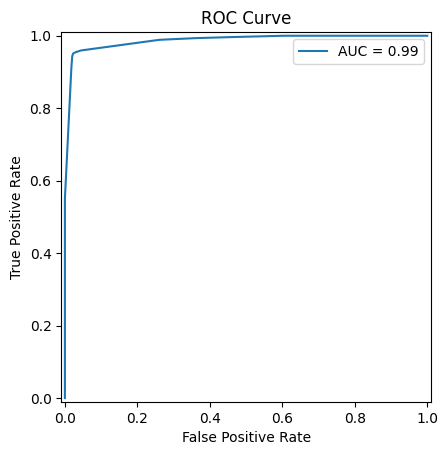

In [ ]:
# Draw ROC Curve for the best model (Decision Tree Classifier with lemmatized dataset)
decision_tree_parameters = {'class_weight': 'balanced', 'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 5}
decision_tree = DecisionTreeClassifier(**decision_tree_parameters, random_state=RANDOM_STATE)
decision_tree.fit(train_tfidf_lemmatized, train_news_labels_lemmatized)

draw_roc_curve(decision_tree, test_tfidf_lemmatized, test_news_labels_lemmatized)

# 2 Model Interpretation (7 points)

a) For your best Logistic Regression model, extract and visualize the weights in a bar plot:
1) Top 10 words most indicative of fake news
2) Top 10 words most indicative of real news

In [ ]:
def visualize_model_weights(model, vectorizer, n_features=10):
    """
    Create a single combined plot with fake news features on top and real news on bottom.
    """
    
    
    # Get features and coefficients
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_[0]
    
    # Top features
    top_real_indices = np.argsort(coefficients)[-n_features:][::-1]
    top_fake_indices = np.argsort(coefficients)[:n_features]
    
    top_real_words = feature_names[top_real_indices]
    top_real_weights = coefficients[top_real_indices]
    top_fake_words = feature_names[top_fake_indices]
    top_fake_weights = coefficients[top_fake_indices]
    
    # Create single figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Combine data
    all_words = np.concatenate([top_fake_words, top_real_words])
    all_weights = np.concatenate([top_fake_weights, top_real_weights])
    
    # Create colors
    colors = ['tab:red' if w < 0 else 'tab:blue' for w in all_weights]
    
    # Plot
    y_pos = np.arange(len(all_words))
    ax.barh(y_pos, all_weights, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_words, fontsize=10)
    ax.set_xlabel('Coefficient Weight', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Features for Fake vs Real News Classification\n(Red: Fake | Blue: Real)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Best logistic regression -> L1 (L1 and L2 have the same metrics)
l1_params = {'penalty':'l1', 'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'}

# Train the L1 model
model_l1 = LogisticRegression(**l1_params, random_state=RANDOM_STATE)
model_l1.fit(train_tfidf, train_news_labels)

LogisticRegression(C=1, penalty='l1', random_state=42, solver='liblinear')

In [ ]:
# Best logistic regression with lemmatized dataset -> L1
l1_lemmatized_params = {'penalty':'l1', 'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'saga'}

# Train the L1 model lemmatized
model_l1_lemmatized = LogisticRegression(**l1_lemmatized_params, random_state=RANDOM_STATE)
model_l1_lemmatized.fit(train_tfidf_lemmatized, train_news_labels_lemmatized)

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=10, class_weight='balanced', penalty='l1', random_state=42,
                   solver='saga')

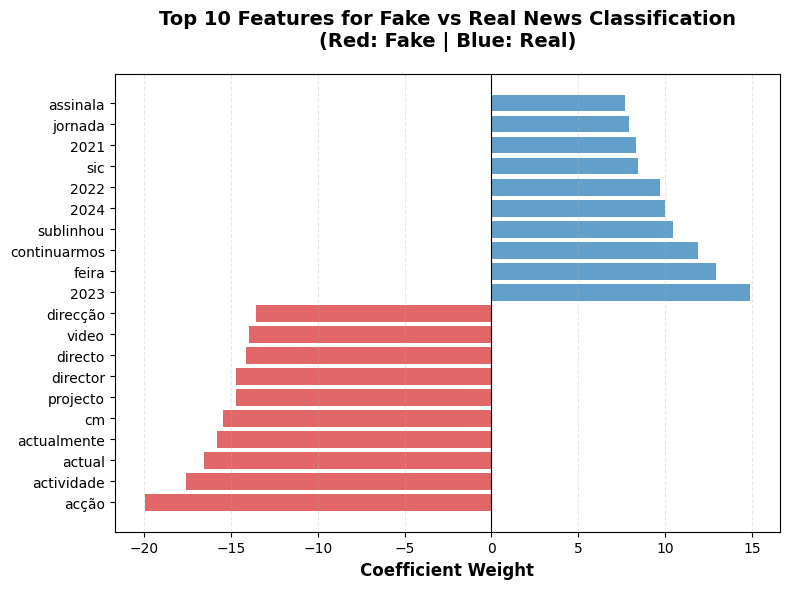


LEMMATIZED


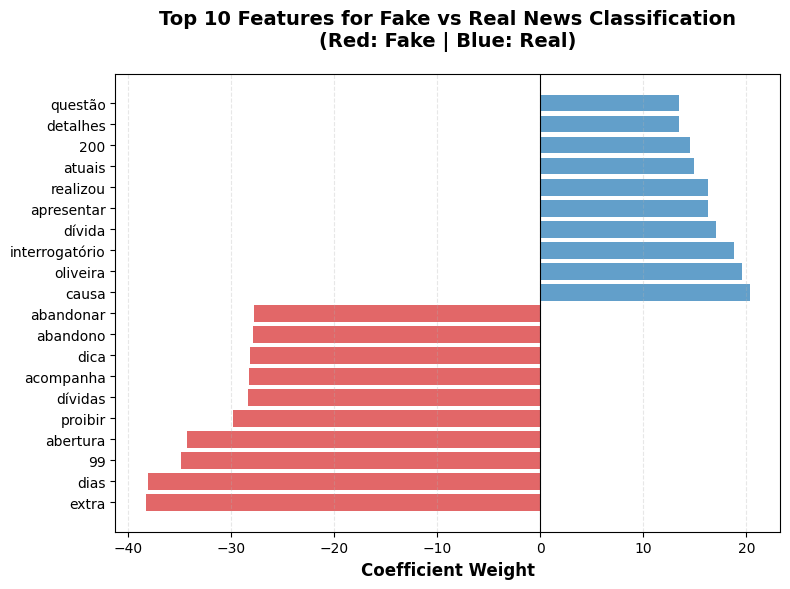

In [ ]:
# Visualize L1 weights with and without lemmatized

visualize_model_weights(
    model=model_l1,
    vectorizer=tfidf_vectorizer,
    n_features=10
)

print("\n" + "="*50)
print("LEMMATIZED")

visualize_model_weights(
    model=model_l1_lemmatized,
    vectorizer=tfidf_vectorizer,
    n_features=10
)

b) Compare L1 vs L2 regularized models: How many features have non-zero weights in each? What
does this tell you about feature selection? When would you prefer L1 vs L2 regularization for
text classification?

In [ ]:
l2_params_lemmatized = {'penalty':'l2', 'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'liblinear'}
model_l2_lemmatized = LogisticRegression(**l2_params_lemmatized, random_state=RANDOM_STATE)
model_l2_lemmatized.fit(train_tfidf_lemmatized, train_news_labels_lemmatized)

LogisticRegression(C=10, class_weight='balanced', random_state=42,
                   solver='liblinear')

In [ ]:
non_zero_weight_count_l1 = (model_l1_lemmatized.coef_[0] != 0).sum()
non_zero_weight_count_l2 = (model_l2_lemmatized.coef_[0] != 0).sum()

print("Number of non-zero weight features:")
print(f"L1 lemmatized: {non_zero_weight_count_l1}")
print(f"L2 lemmatized: {non_zero_weight_count_l2}")

Number of non-zero weight features:
L1 lemmatized: 4437
L2 lemmatized: 5000


L1 regularization pushes some weights exactly to zero, effectively removing those features from the model. In contrast, L2 regularization spreads the weight values more evenly, shrinking them without eliminating any feature entirely.

Our results reflect this behaviour: the L2-regularized model ends up with 5 000 non-zero weights, meaning all features still contribute to the classification, whereas the L1-regularized model sets 563 of them to zero. This makes the L1 model more computationally efficient and its decisions easier to interpret — an advantage when dealing with very high-dimensional data.

However, there are situations where many features contribute only weakly on their own but have a meaningful cumulative effect. In such cases, removing them entirely can harm the model’s performance. For those scenarios, L2 regularization is more appropriate.

Comparative Analysis of L1 and L2 Regularization

A fundamental distinction between L1 and L2 regularization lies in their feature selection behavior. L1 regularization performs automatic feature selection by setting numerous coefficients to exactly zero, retaining only non-zero features from the original 5,000 TF-IDF features. In contrast, L2 regularization maintains nearly all features with non-zero weights, shrinking coefficients toward zero without eliminating them entirely. This sparsity property makes L1 models more interpretable and computationally efficient, while L2 models distribute weights across the feature space, handling correlated features more gracefully.

Both models identified similar top discriminative features, with terms like "feira" and "sic" indicating fake news, and "actual" and "actividade" signaling authentic content. However, L2 achieved marginally superior performance (accuracy: 0.8945 vs 0.8909), suggesting that retaining additional features with small weights provides incremental predictive value.

Selection Criteria: L1 regularization is preferable when model interpretability, dimensionality reduction, or deployment efficiency are priorities, as it explicitly identifies the most important features. L2 regularization is advantageous when maximizing predictive accuracy is paramount, particularly in contexts with multicollinearity or when many features contribute weak but cumulative signals. For Portuguese fake news detection, L1 offers valuable linguistic insights for understanding misinformation patterns, while L2 provides optimal performance for automated content moderation systems where accuracy is critical.

c) For your best Logistic Regression model, select samples in the validation set with ID 2921,
2437, 5557, 1697, and extract explanations with LIME (Ribeiro et al., 2016; Lundberg and
Lee, 2017).

In [ ]:
def explain_with_lime(
    model,
    dataset_path,
    samples_indices: list,
    tf_idf_vectorizer: TfidfVectorizer,
    class_names:list,
    max_features : int = 10
):
    dataset = pd.read_csv(dataset_path)
    explainer = LimeTextExplainer(class_names=class_names)
    pipeline = make_pipeline(tf_idf_vectorizer, model)

    for idx in samples_indices:

        exp = explainer.explain_instance(
            dataset.iloc[idx]['Text'], 
            pipeline.predict_proba, 
            num_features=max_features
        )
        print('\nDocument id: %d' % idx)

        print('\nProbability(True) =', pipeline.predict_proba([dataset.iloc[idx]['Text']])[0,1])

        print('\nTrue class: %s\n' % class_names[dataset.iloc[idx]['Label']])

        print(exp.as_list())

        exp.as_pyplot_figure()

In [ ]:
DATASET_PATH = "../data/val.csv"
INDICES = [2921, 2437, 5557, 1697]
CLASS_NAMES = ["Fake", "True"]

explain_with_lime(
    model_l2,
    dataset_path=DATASET_PATH,
    samples_indices=INDICES,
    tf_idf_vectorizer=tfidf_vectorizer,
    class_names=CLASS_NAMES
)




Document id: 2921

Probability(True) = 0.9999888717293159

True class: True

[(np.str_('temporada'), 0.005015059332464842), (np.str_('Liga'), 0.0043129148100004774), (np.str_('lateral'), 0.004270737299459839), (np.str_('internacional'), 0.003451037743367228), (np.str_('equipa'), 0.003312518606684301), (np.str_('espanhol'), 0.0030866183710244956), (np.str_('ex'), 0.0030325855298310644), (np.str_('Sporting'), -0.0005202247423520682), (np.str_('assinou'), -0.0004433256808997049), (np.str_('jovem'), 8.742873414105787e-05)]


Document id: 2437

Probability(True) = 0.0009262043151451551

True class: Fake

[(np.str_('filha'), -0.011271575252603984), (np.str_('tudo'), -0.010147570522073933), (np.str_('podes'), -0.009185641738597766), (np.str_('etc'), -0.0090979116794423), (np.str_('vida'), -0.0062368935459681425), (np.str_('extremamente'), -0.005997404360032106), (np.str_('gostava'), -0.0057208142989165125), (np.str_('disse'), 0.005690029955136383), (np.str_('importante'), 0.00518495636838389

d) For your MLP, select samples in the validation set with ID 2921, 2437, 5557, 1697, and
extract explanations with LIME and permutation importance. For permutation importance,
select 1K random samples. Visualize the results and discuss their differences.

In [ ]:
mlp_params = {'solver': 'adam', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (64, 32), 'alpha': 1e-05, 'activation': 'relu'} 

mlp_model = MLPClassifier(**mlp_params, random_state=RANDOM_STATE)

mlp_model.fit(train_tfidf, train_news_labels)

DATASET_PATH = "../data/val.csv"
INDICES = [2921, 2437, 5557, 1697]
CLASS_NAMES = ["Fake", "True"]

explain_with_lime(
    mlp_model,
    dataset_path=DATASET_PATH,
    samples_indices=INDICES,
    tf_idf_vectorizer=tfidf_vectorizer,
    class_names=CLASS_NAMES
)




Document id: 2921

Probability(True) = 0.9999999999999916

True class: True

[(np.str_('temporadas'), 0.00291640838451484), (np.str_('temporada'), 0.0028816450549505423), (np.str_('Liga'), 0.002674641931009512), (np.str_('passe'), 0.0025713223225063537), (np.str_('Inglaterra'), 0.0025695413054079666), (np.str_('contratar'), 0.0023284950624942614), (np.str_('defesa'), -0.0008414789396793457), (np.str_('Os'), 0.0007857963471847575), (np.str_('assinou'), 0.00046018517909283616), (np.str_('Tiago'), 8.501785179847926e-05)]


Document id: 2437

Probability(True) = 7.4318528946489e-19

True class: Fake

[(np.str_('filha'), -0.002254938831771541), (np.str_('podes'), -0.0022029723719869366), (np.str_('bom'), -0.0021073001038392426), (np.str_('impedi'), -0.0020664755066820274), (np.str_('nada'), -0.001885260973371469), (np.str_('seguiram'), 0.0017837674641860185), (np.str_('fora'), -0.0017177746559505671), (np.str_('tens'), -0.0017089140264803506), (np.str_('disse'), 0.0016187551810271214), (np

Top 20 most important features:
         feature  importance_mean  importance_std
2332   glifosato         0.003649        0.000449
2985      menina         0.003095        0.000809
1030   comprando         0.003038        0.000500
2103       feira         0.002613        0.002440
3464       pedem         0.002184        0.000000
4485         sul         0.002177        0.001034
1254       costa         0.002174        0.000929
993      comenta         0.002165        0.000056
4741         tvi         0.002121        0.001092
3330    ordenado         0.002065        0.000901
422      arguido         0.002056        0.000552
1579   difundida         0.002046        0.000618
521   atividades         0.002018        0.000834
1959     euribor         0.001995        0.000808
738        caixa         0.001956        0.000706
2408       homem         0.001956        0.000706
3618        pois         0.001940        0.001442
4066       reino         0.001890        0.000750
1507      desses  

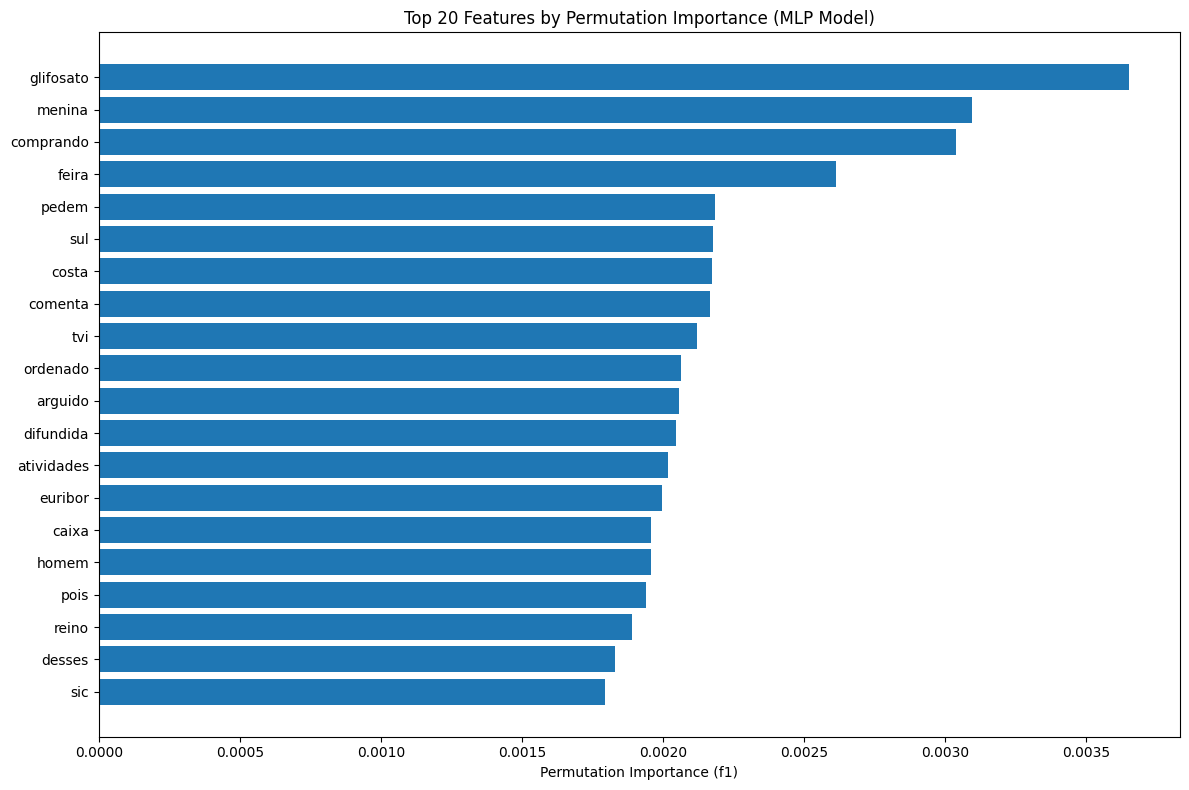

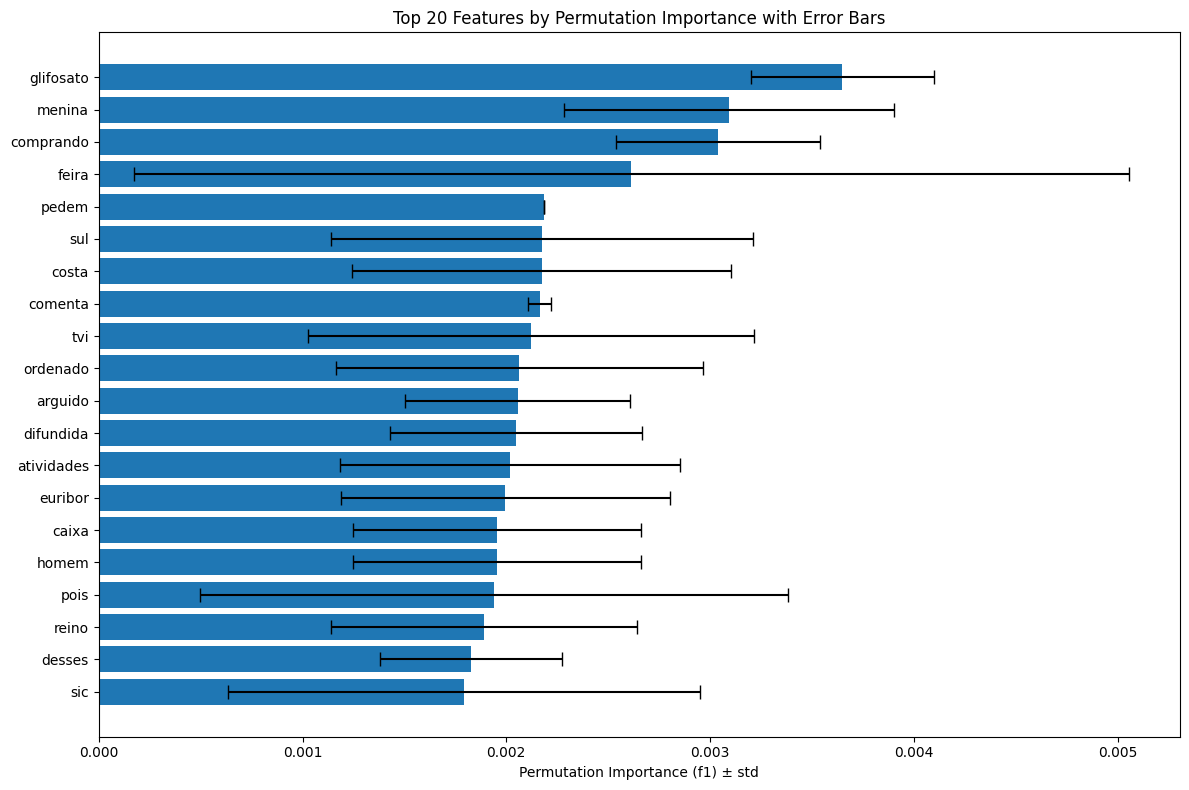

In [ ]:
# Select 1K random samples for permutation importance
SIZE = 1000
REPLACE = False
RANDOM_STATE = 42
N_REPEATS = 10
SCORING = 'f1'

np.random.seed(RANDOM_STATE)
random_indices = np.random.choice(len(val_fake_news_df), size=SIZE, replace=REPLACE)
perm_samples = val_fake_news_df.iloc[random_indices]

# Extract features and labels for permutation samples
X_perm = perm_samples['Text'].values
y_perm = perm_samples['Label'].values

# Transform text to features
X_perm_transformed = tfidf_vectorizer.transform(X_perm)

# Convert sparse matrix to dense array
X_perm_dense = X_perm_transformed.toarray()

# Method 1: Using sklearn's permutation_importance
perm_importance = permutation_importance(
    mlp_model,  
    X_perm_dense,  # Use dense array instead of sparse
    y_perm,
    n_repeats=N_REPEATS,  
    random_state=RANDOM_STATE,
    scoring=SCORING,  
    n_jobs=-1  
)

# Get feature names from TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a dataframe with results
perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Display top features
print("Top 20 most important features:")
print(perm_importance_df.head(20))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
top_features = perm_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance_mean'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel(f'Permutation Importance ({SCORING})')
plt.title('Top 20 Features by Permutation Importance (MLP Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Also show with error bars
plt.figure(figsize=(12, 8))
top_features = perm_importance_df.head(20)
plt.barh(
    range(len(top_features)), 
    top_features['importance_mean'],
    xerr=top_features['importance_std'],
    capsize=5
)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel(f'Permutation Importance ({SCORING}) ± std')
plt.title('Top 20 Features by Permutation Importance with Error Bars')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3 Clustering (3 points)

a) Apply K-Means with K=5 on your training set.

In [ ]:
K = 5
MAX_ITER = 500
kmeans_model = KMeans(n_clusters=K, max_iter=500, random_state=RANDOM_STATE)
kmeans_model.fit(train_tfidf_lemmatized)


/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


KMeans(max_iter=500, n_clusters=5, random_state=42)

b) Inspect 3 documents closest to each centroid, and afterwards, assign semantic labels to each
cluster (e.g., “political fake news”, “health misinformation”).

In [ ]:
centroids = kmeans_model.cluster_centers_
distances = cosine_distances(train_tfidf_lemmatized, centroids)

top_docs_per_cluster = {}


for c in range(K):
    sorted_idx = np.argsort(distances[:, c])
    top3 = sorted_idx[:3]
    top_docs_per_cluster[c] = top3


for c in range(K):
    print("\n" + "="*60)
    print(f"Cluster {c} — Top 3 documents:")

    for rank, doc_id in enumerate(top_docs_per_cluster[c], start=1):
        text = train_fake_news_df_lemmatized.iloc[doc_id]["Text"]
        print(f"\n[{rank}] Document #{doc_id}")
        print(text[:400], "...\n")


feature_names = tfidf_vectorizer_lemmatized.get_feature_names_out()
labels = kmeans_model.labels_

top_terms_per_cluster = {}

for c in range(K):
    cluster_docs = train_tfidf_lemmatized[labels == c]
    mean_tfidf = cluster_docs.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:10]
    keywords = [feature_names[i] for i in top_idx]

    top_terms_per_cluster[c] = keywords
    print("\nCluster", c, "keywords:", ", ".join(keywords))



Cluster 0 — Top 3 documents:

[1] Document #43498
grupo Wagner contradizr Putin o força ucraniano estar a avançar Putin dizer que o contraofensivo ucraniano ter ser um fracasso mas o líder de o grupo Wagner desmentir e dizer que não haver controlo nem sucesso militar por parte de Moscovo o exército russo estar a recuar em vários setor de o sul e leste de o Ucrânia afirmar este sexta-feira o líder de o grupo paramilitar Wagner contradizer o afirma ...


[2] Document #4395
Putin admitir criar zona sanitário em o território ucraniano devido a ataque junto a o fronteira presidente russo dizer que alguém poder ter suposto que o força ucraniano ir avançar com um contraofensivo Vladimir Putin admitir este terça-feira que o Rússia poder ter preparar com mais sucesso o região de o sul de o país que fazer fronteira com o Ucrânia para ataque transfronteiriço a partir de o te ...


[3] Document #25101
o principal momento que marcar o mês de guerra em o Ucrânia o conflito armar entre o Rússia e o 

c) Visualize clusters in 2D using PCA. Create two plots: one colored by cluster assignment, one by
true label.

In [ ]:
N_COMPONENTS = 2

pca = PCA(n_components=N_COMPONENTS)
tfidf_2d = pca.fit_transform(train_tfidf_lemmatized.toarray())

# Extract coordinates
x = tfidf_2d[:, 0]
y = tfidf_2d[:, 1]

# Cluster assignments from kmeans
cluster_labels = kmeans_model.labels_

# True labels
true_labels = train_fake_news_df_lemmatized["Label"]

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/emaferrao/Projects/NTT_Data_meri

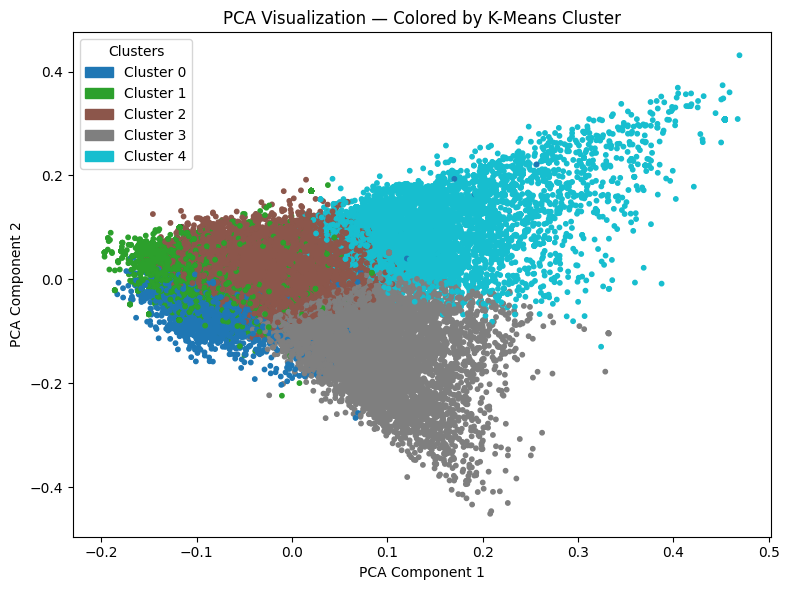

In [ ]:
unique_labels = np.unique(cluster_labels)

plt.figure(figsize=(8, 6))

# Scatter plot
scatter = plt.scatter(x, y, c=cluster_labels, cmap='tab10', s=10)

plt.title("PCA Visualization — Colored by K-Means Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Extract colors used (to use the same in the legend)
colors = scatter.cmap(scatter.norm(unique_labels))
legend_handles = [
    Patch(color=colors[i], label=f"Cluster {unique_labels[i]}")
    for i in range(len(unique_labels))
]

plt.legend(handles=legend_handles, title="Clusters", loc='upper left')

plt.tight_layout()
plt.show()

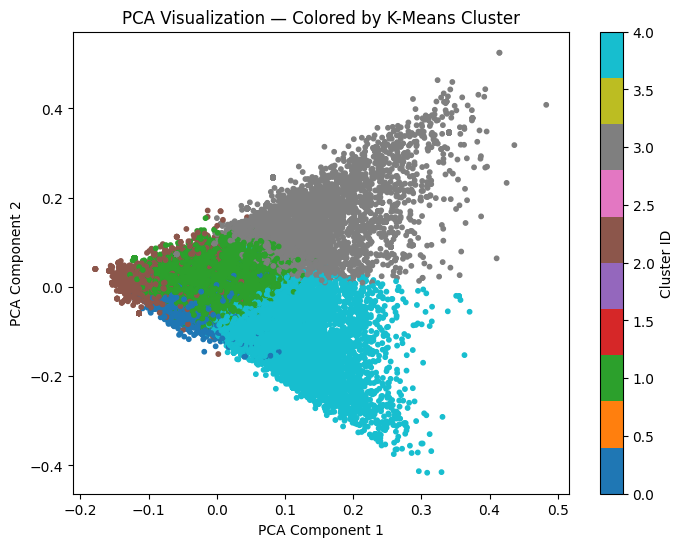

In [ ]:
# plot using the cluster assigments
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=cluster_labels, cmap='tab10', s=10)
plt.title("PCA Visualization — Colored by K-Means Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster ID")
plt.show()

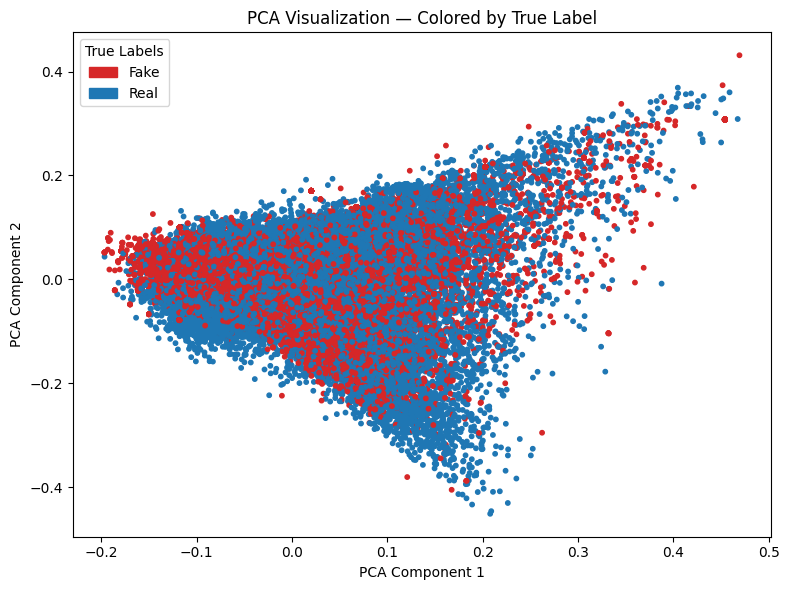

In [ ]:
# plot using the true labels

true_codes = true_labels.values 
unique_codes = np.unique(true_codes)
label_names = {0: "Fake", 1: "Real"}
custom_colors = {0: "tab:red", 1: "tab:blue"}

plt.figure(figsize=(8, 6))

# Scatter plot (color by true label codes)
scatter = plt.scatter(
    x, y,
    color=[custom_colors[c] for c in true_codes],
    s=10
)

plt.title("PCA Visualization — Colored by True Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

legend_handles = [
    Patch(color=custom_colors[code], label=label_names[code])
    for code in unique_codes
]

plt.legend(
    handles=legend_handles,
    title="True Labels",
    loc="upper left"
)

plt.tight_layout()
plt.show()

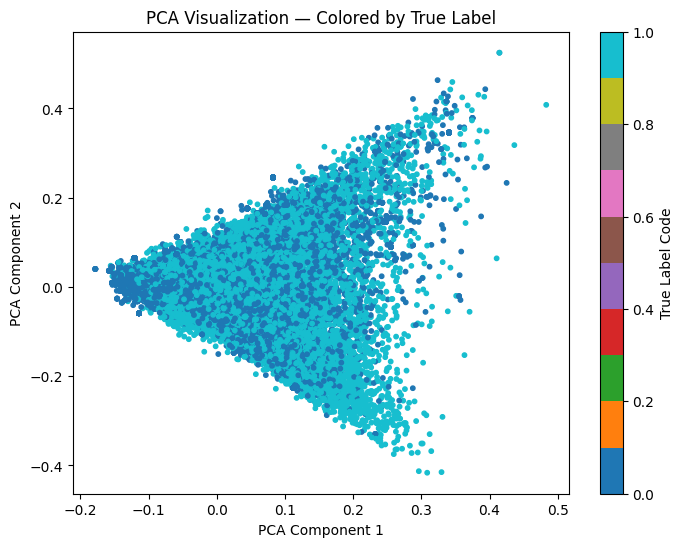

In [ ]:
# plot using the true labels
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=true_labels.astype('category').cat.codes, cmap='tab10', s=10)
plt.title("PCA Visualization — Colored by True Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="True Label Code")
plt.show()